# 01 — Exploratory Data Analysis

Understand the dataset before modelling: churn rates by segment, feature distributions, and correlation with the target.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df["Churn"] = (df["Churn"] == "Yes").astype(int)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

print(f"Shape: {df.shape}")
print(f"Churn rate: {df.Churn.mean():.3f}  ({df.Churn.sum()} churners)")

Shape: (7032, 21)
Churn rate: 0.266  (1869 churners)


## Churn rate by key segments

In [2]:
print("Churn rate by Contract type:")
print(df.groupby("Contract")["Churn"].mean().round(3).sort_values(ascending=False))
print()
df["tenure_bucket"] = pd.cut(df["tenure"], bins=[0,12,24,48,72],
                               labels=["0-12m","13-24m","25-48m","49-72m"])
print("Churn rate by tenure:")
print(df.groupby("tenure_bucket")["Churn"].mean().round(3))

Churn rate by Contract type:
Contract
Month-to-month    0.427
One year          0.113
Two year          0.028
Name: Churn, dtype: float64

Churn rate by tenure:
tenure_bucket
0-12m     0.477
13-24m    0.287
25-48m    0.204
49-72m    0.095
Name: Churn, dtype: float64


## Feature correlations with Churn

In [3]:
num_cols = ["tenure","MonthlyCharges","TotalCharges","SeniorCitizen"]
corr = df[num_cols + ["Churn"]].corr()["Churn"].drop("Churn").sort_values()
print(corr.round(4))

tenure           -0.3540
TotalCharges     -0.1995
SeniorCitizen     0.1505
MonthlyCharges    0.1929
Name: Churn, dtype: float64


## Visualise distributions

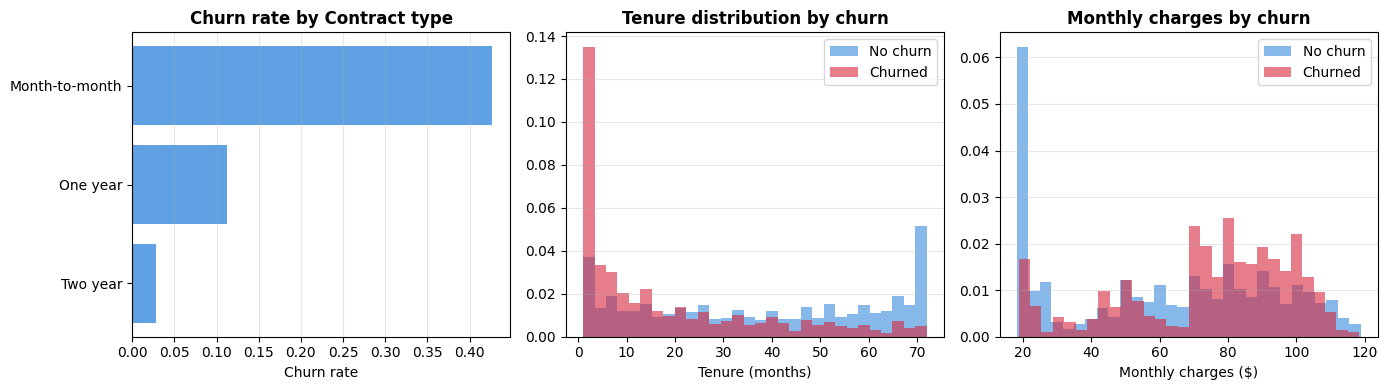

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Churn rate by contract
contract_churn = df.groupby("Contract")["Churn"].mean().sort_values()
axes[0].barh(contract_churn.index, contract_churn.values, color="#378ADD", alpha=0.8)
axes[0].set_xlabel("Churn rate")
axes[0].set_title("Churn rate by Contract type", fontweight="bold")
axes[0].grid(axis="x", alpha=0.3)

# Tenure distribution by churn
axes[1].hist(df[df.Churn==0]["tenure"], bins=30, alpha=0.6, color="#378ADD", label="No churn", density=True)
axes[1].hist(df[df.Churn==1]["tenure"], bins=30, alpha=0.6, color="#D7263D", label="Churned", density=True)
axes[1].set_xlabel("Tenure (months)")
axes[1].set_title("Tenure distribution by churn", fontweight="bold")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

# Monthly charges distribution
axes[2].hist(df[df.Churn==0]["MonthlyCharges"], bins=30, alpha=0.6, color="#378ADD", label="No churn", density=True)
axes[2].hist(df[df.Churn==1]["MonthlyCharges"], bins=30, alpha=0.6, color="#D7263D", label="Churned", density=True)
axes[2].set_xlabel("Monthly charges ($)")
axes[2].set_title("Monthly charges by churn", fontweight="bold")
axes[2].legend()
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()